#  OBJECTIVE

**This notebook focuses on cleaning and preprocessing raw flight data** — handling missing values, standardising categorical fields, parsing datetime features, and detecting price outliers — to produce a reliable, ML-ready dataset for flight price prediction.

> **Dataset:** 10,683 Indian domestic flight records (2019) | 11 raw features | Target: `Price` (INR)

TASK 1 -
Load dataset, inspect structure, check memory usage

---
##  Step: Data Loading & Structural Inspection

**Why:** Before any modelling, we must understand the dataset's shape, data types, memory footprint, and statistical distribution. This baseline audit reveals whether columns are correctly typed, identifies object columns that need parsing, and flags the only numerical target (`Price`) for later transformation.

In [ ]:
!pip install seaborn
!pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"D:\brainy_beams\AirFair-Vista\data\raw\flight_price_raw.csv")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
df.shape

(10683, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
df.describe(include='all') #include = all includes give statistical summery with cat. cols also

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683,10683.000000
unique,12,44,5,6,128,222,1343,368,5,10,NaN
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info,NaN
freq,3849,504,4537,4537,2376,233,423,550,5625,8345,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9087.064121
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4611.359167
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1759.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5277.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8372.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12373.000000


In [ ]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [ ]:
df.memory_usage(deep=True)

Index                  132
Airline             713731
Date_of_Journey     711590
Source              676138
Destination         682774
Route              1173880
Dep_Time            662346
Arrival_Time        692691
Duration            673037
Total_Stops         681546
Additional_Info     730311
Price                85464
dtype: int64

In [ ]:
df.memory_usage(deep=True).sum() / 1024**2 # conver whole into mb

np.float64(7.136955261230469)

---
## 🔷 Step: Missing Value Analysis & Imputation

**Why:** ML models cannot tolerate `NaN` entries. Here, `Route` and `Total_Stops` each have exactly **1 missing row** — and it is the *same* row (index 9039). Since both structural columns are absent simultaneously, imputation is unreliable; dropping this single row preserves data integrity without meaningful loss (< 0.01 % of 10,683 records).

TASK 2
Missing Value Analysis + Imputation

In [ ]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [ ]:
df[df['Route'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [ ]:
df[df['Total_Stops'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [ ]:
df.dropna(subset=['Route','Total_Stops'], how='all', inplace=True)

In [ ]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 1001.4+ KB


---
## 🔷 Step: Datetime Feature Extraction

**Why:** Raw date/time strings (`Date_of_Journey`, `Dep_Time`) carry no mathematical meaning for a regression model. Decomposing them into numeric components — `journey_day`, `journey_month`, `journey_weekday`, `is_weekend`, `quarter`, `dep_hour`, `dep_time_bin` — allows the model to learn temporal pricing patterns (e.g., weekend surges, peak-hour premiums).

TASK 3
Convert Datetime Columns|

In [ ]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')

df['journey_day'] = df['Date_of_Journey'].dt.day
df['journey_month'] = df['Date_of_Journey'].dt.month
df['journey_weekday'] = df['Date_of_Journey'].dt.weekday
df['is_weekend'] = df['journey_weekday'].apply(lambda x: 1 if x >= 5 else 0)
df['quarter'] = df['Date_of_Journey'].dt.quarter

Monday    → 0
Tuesday   → 1
Wednesday → 2
Thursday  → 3
Friday    → 4
Saturday  → 5
Sunday    → 6

Jan–Mar   → 1
Apr–Jun   → 2
Jul–Sep   → 3
Oct–Dec   → 4

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,is_weekend,quarter
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,6,1,1
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2,0,2
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,6,1,2
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,6,1,2
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,4,0,1


In [ ]:
df['dep_hour'] = df['Dep_Time'].dt.hour

bins = [0, 5, 12, 17, 21, 24]
labels = ["Late Night", "Morning", "Afternoon", "Evening", "Night"]

df['dep_time_bin'] = pd.cut(
    df['dep_hour'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,is_weekend,quarter,dep_hour,dep_time_bin
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-02-27 22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,6,1,1,22,Night
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-02-27 05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,2,0,2,5,Morning
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-02-27 09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,6,1,2,9,Morning
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-02-27 18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,6,1,2,18,Evening
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-02-27 16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,4,0,1,16,Afternoon


In [ ]:
df['Dep_Time'] = df['Dep_Time'].dt.time

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,is_weekend,quarter,dep_hour,dep_time_bin
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,6,1,1,22,Night
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,2,0,2,5,Morning
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,6,1,2,9,Morning
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,6,1,2,18,Evening
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,4,0,1,16,Afternoon


---
## 🔷 Step: Categorical Inconsistency Detection & Standardisation

**Why:** Inconsistent casing or whitespace in `Airline`, `Source`, and `Destination` would cause label-encoders or one-hot encoders to treat identical values as different categories (e.g., "IndiGo" vs "indigo"), inflating dimensionality and corrupting frequency statistics. Lowercasing + stripping ensures clean, deterministic encoding in the next notebook.

TASK 4
Detect & Handle Categorical Inconsistencies

In [ ]:
df['Airline'].unique()


array(['indigo', 'air india', 'jet airways', 'spicejet',
       'multiple carriers', 'goair', 'vistara', 'air asia',
       'vistara premium economy', 'jet airways business',
       'multiple carriers premium economy', 'trujet'], dtype=object)

In [ ]:
df['Source'].unique()


array(['banglore', 'kolkata', 'delhi', 'chennai', 'mumbai'], dtype=object)

In [ ]:
df['Destination'].unique()

array(['new delhi', 'banglore', 'cochin', 'kolkata', 'delhi', 'hyderabad'],
      dtype=object)

In [ ]:
df['Airline'] = df['Airline'].str.strip().str.lower()

In [ ]:
df['Airline']

0             indigo
1          air india
2        jet airways
3             indigo
4             indigo
            ...     
10678       air asia
10679      air india
10680    jet airways
10681        vistara
10682      air india
Name: Airline, Length: 10682, dtype: object

In [ ]:
df['Source'] = df['Source'].str.strip().str.lower()
df['Source']

0        banglore
1         kolkata
2           delhi
3         kolkata
4        banglore
           ...   
10678     kolkata
10679     kolkata
10680    banglore
10681    banglore
10682       delhi
Name: Source, Length: 10682, dtype: object

In [ ]:
df['Destination'] = df['Destination'].str.strip().str.lower()
df['Destination']

0        new delhi
1         banglore
2           cochin
3         banglore
4        new delhi
           ...    
10678     banglore
10679     banglore
10680        delhi
10681    new delhi
10682       cochin
Name: Destination, Length: 10682, dtype: object

---
## 🔷 Step: Outlier Detection in `Price` (IQR Method)

**Why:** Flight prices contain extreme values (business/premium cabins, last-minute bookings) that skew model learning. IQR fencing identifies 94 outlier records, and skewness analysis (value > 1.8) confirms heavy right-skew — justifying log-transformation as the preferred target-encoding strategy.

TASK 5
Outlier Detection (IQR + Z-score)

In [ ]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
len(outliers_iqr)

94

In [ ]:
df['Price'].describe()

count    10682.000000
mean      9087.214567
std       4611.548810
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64

<Axes: xlabel='Price'>

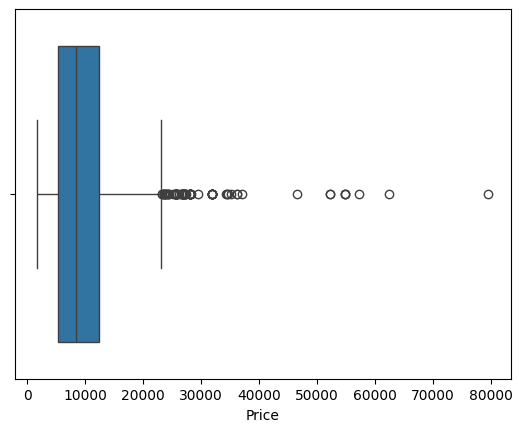

In [ ]:
import seaborn as sns
sns.boxplot(x=df['Price'])

### 📈 Graph Insight — Boxplot of `Price`

- **Pattern:** The box spans roughly ₹5,000–₹12,000 with a median near ₹8,400; a long right whisker and multiple far-right points (up to ₹79,512) confirm extreme high-price outliers.
- **Flight pricing meaning:** Premium economy/business-class tickets and last-minute bookings create a long upper tail — this is expected and domain-valid, not data error.
- **Model impact:** These outliers will bias regression models toward over-predicting expensive tickets. Three target versions (`Price_original`, `Price_capped`, `Price_log`) are retained for comparison in later modelling notebooks.

In [ ]:
df['Price'].skew() #check skewness here skew is >1 = Strong skew, so log we choose

np.float64(1.812404554693161)

We create 3 versions

In [ ]:
# Original
y_original = df['Price']

# Capped
df['Price_capped'] = df['Price'].clip(lower_bound, upper_bound)
y_capped = df['Price_capped']

# Log
import numpy as np
df['Price_log'] = np.log1p(df['Price'])
y_log = df['Price_log']

---
## 🔄 Next Step → Notebook 02: Feature Engineering

The cleaned dataset (`flight_price_cleaned.csv`) now contains standardised categorical fields, parsed datetime components, and three versions of the price target. **Notebook 02** will build on this by extracting flight duration in minutes from the raw `Duration` string, computing stop-count as a numeric variable, and constructing additional domain features (route complexity, time-to-departure proxies) that will drive model performance.

In [ ]:
df.to_csv(r"D:\brainy_beams\AirFair-Vista\data\processed/flight_price_cleaned.csv", index=False)